In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [35]:
df=pd.read_csv("dataset.csv")
df


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0


## Feauture Engineering

In [36]:

df['Cost_per_gram'] = df['Cost_of_the_Product'] / (df['Weight_in_gms'] )
df['Discount_ratio'] = df['Discount_offered'] / (df['Cost_of_the_Product'] )  
df['Rating_vs_calls'] = df['Customer_rating'] / (df['Customer_care_calls'] + 1)

In [37]:

#Just an identifier, does not affect shipment delivery. Should be dropped
df.drop("ID", axis=1, inplace=True) 
target=df["Reached.on.Time_Y.N"]
df.drop("Reached.on.Time_Y.N", axis=1, inplace=True) 
df

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Cost_per_gram,Discount_ratio,Rating_vs_calls
0,D,Flight,4,2,177,3,low,F,44,1233,0.143552,0.248588,0.400000
1,F,Flight,4,5,216,2,low,M,59,3088,0.069948,0.273148,1.000000
2,A,Flight,2,2,183,4,low,M,48,3374,0.054238,0.262295,0.666667
3,B,Flight,3,3,176,4,medium,M,10,1177,0.149533,0.056818,0.750000
4,C,Flight,2,2,184,3,medium,F,46,2484,0.074074,0.250000,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10994,A,Ship,4,1,252,5,medium,F,1,1538,0.163849,0.003968,0.200000
10995,B,Ship,4,1,232,5,medium,F,6,1247,0.186047,0.025862,0.200000
10996,C,Ship,5,4,242,5,low,F,4,1155,0.209524,0.016529,0.666667
10997,F,Ship,5,2,223,6,medium,M,2,1210,0.184298,0.008969,0.333333


In [38]:
df_num = df.select_dtypes(include=np.number)
df_cat=df.select_dtypes(exclude=np.number)


### Check Distribution of Numerical Features
- If data is normally distributed → use StandardScaler.

- If data is skewed / has outliers → use RobustScaler or log transform.

- If you need values between 0–1 → use MinMaxScaler.

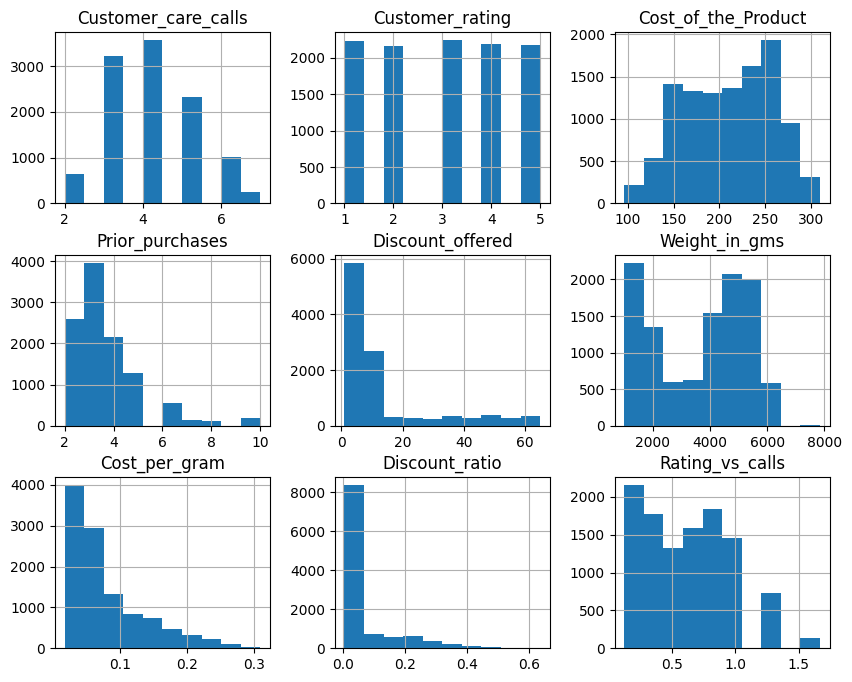

In [8]:
df_num.hist(figsize=(10,8))
plt.show()

In [39]:
df_num.skew()

Customer_care_calls    0.391926
Customer_rating        0.004360
Cost_of_the_Product   -0.157117
Prior_purchases        1.681897
Discount_offered       1.798929
Weight_in_gms         -0.249747
Cost_per_gram          1.419781
Discount_ratio         2.172764
Rating_vs_calls        0.581421
dtype: float64

## Feauture Scaling
The numerical features have different scales, which can negatively impact distance-based algorithms like SVM and Logistic Regression. Standard Scaling is an appropriate method to normalize these features.

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[df_num.columns]= scaler.fit_transform(df_num)
df

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Cost_per_gram,Discount_ratio,Rating_vs_calls
0,D,Flight,-0.047711,-0.700755,-0.690722,-0.372735,low,F,1.889983,-1.468240,1.150475,1.924300,-0.664751
1,F,Flight,-0.047711,1.421578,0.120746,-1.029424,low,M,2.815636,-0.333893,-0.165997,2.189294,1.127835
2,A,Flight,-1.799887,-0.700755,-0.565881,0.283954,low,M,2.136824,-0.159002,-0.446982,2.072196,0.131954
3,B,Flight,-0.923799,0.006689,-0.711529,0.283954,medium,M,-0.208162,-1.502484,1.257440,-0.144777,0.380925
4,C,Flight,-1.799887,-0.700755,-0.545074,-0.372735,medium,F,2.013404,-0.703244,-0.092202,1.939539,0.131954
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10994,A,Ship,-0.047711,-1.408199,0.869792,0.940643,medium,F,-0.763553,-1.281730,1.513501,-0.714997,-1.262279
10995,B,Ship,-0.047711,-1.408199,0.453655,0.940643,medium,F,-0.455002,-1.459679,1.910520,-0.478775,-1.262279
10996,C,Ship,0.828377,0.714133,0.661724,0.940643,low,F,-0.578423,-1.515937,2.330431,-0.579474,0.131954
10997,F,Ship,0.828377,-0.700755,0.266394,1.597332,medium,M,-0.701843,-1.482304,1.879238,-0.661046,-0.863927


In [41]:
df[df_num.columns].mean().round(1)

Customer_care_calls    0.0
Customer_rating       -0.0
Cost_of_the_Product   -0.0
Prior_purchases       -0.0
Discount_offered      -0.0
Weight_in_gms         -0.0
Cost_per_gram         -0.0
Discount_ratio        -0.0
Rating_vs_calls        0.0
dtype: float64

In [42]:
df[df_num.columns].std().round(1)

Customer_care_calls    1.0
Customer_rating        1.0
Cost_of_the_Product    1.0
Prior_purchases        1.0
Discount_offered       1.0
Weight_in_gms          1.0
Cost_per_gram          1.0
Discount_ratio         1.0
Rating_vs_calls        1.0
dtype: float64

##  Encoding
Label Encoding (which maps them to numbers like 0, 1, 2) makes sense.

By contrast, columns like Mode_of_Shipment, Warehouse_block, or Gender have no natural order,
so they should use OneHotEncoder.

In [43]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd


encoder = LabelEncoder()
a=df["Product_importance"]
df.drop("Product_importance",axis=1,inplace=True)
df["Product_importance"] = encoder.fit_transform(a)

df

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Gender,Discount_offered,Weight_in_gms,Cost_per_gram,Discount_ratio,Rating_vs_calls,Product_importance
0,D,Flight,-0.047711,-0.700755,-0.690722,-0.372735,F,1.889983,-1.468240,1.150475,1.924300,-0.664751,1
1,F,Flight,-0.047711,1.421578,0.120746,-1.029424,M,2.815636,-0.333893,-0.165997,2.189294,1.127835,1
2,A,Flight,-1.799887,-0.700755,-0.565881,0.283954,M,2.136824,-0.159002,-0.446982,2.072196,0.131954,1
3,B,Flight,-0.923799,0.006689,-0.711529,0.283954,M,-0.208162,-1.502484,1.257440,-0.144777,0.380925,2
4,C,Flight,-1.799887,-0.700755,-0.545074,-0.372735,F,2.013404,-0.703244,-0.092202,1.939539,0.131954,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10994,A,Ship,-0.047711,-1.408199,0.869792,0.940643,F,-0.763553,-1.281730,1.513501,-0.714997,-1.262279,2
10995,B,Ship,-0.047711,-1.408199,0.453655,0.940643,F,-0.455002,-1.459679,1.910520,-0.478775,-1.262279,2
10996,C,Ship,0.828377,0.714133,0.661724,0.940643,F,-0.578423,-1.515937,2.330431,-0.579474,0.131954,1
10997,F,Ship,0.828377,-0.700755,0.266394,1.597332,M,-0.701843,-1.482304,1.879238,-0.661046,-0.863927,2


In [44]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

encoder = OneHotEncoder(sparse_output=False,drop="first")
encoded = encoder.fit_transform(df[["Warehouse_block","Mode_of_Shipment","Gender"]])

print(encoded)
print(encoder.get_feature_names_out())

[[0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 ...
 [0. 1. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 1.]
 [0. 0. 1. ... 0. 1. 0.]]
['Warehouse_block_B' 'Warehouse_block_C' 'Warehouse_block_D'
 'Warehouse_block_F' 'Mode_of_Shipment_Road' 'Mode_of_Shipment_Ship'
 'Gender_M']


In [45]:
df_encoded = pd.DataFrame(encoded,columns = encoder.get_feature_names_out())
df = pd.concat([df,df_encoded],axis=1)
df

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Gender,Discount_offered,Weight_in_gms,Cost_per_gram,Discount_ratio,Rating_vs_calls,Product_importance,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Gender_M
0,D,Flight,-0.047711,-0.700755,-0.690722,-0.372735,F,1.889983,-1.468240,1.150475,1.924300,-0.664751,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,F,Flight,-0.047711,1.421578,0.120746,-1.029424,M,2.815636,-0.333893,-0.165997,2.189294,1.127835,1,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,A,Flight,-1.799887,-0.700755,-0.565881,0.283954,M,2.136824,-0.159002,-0.446982,2.072196,0.131954,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,B,Flight,-0.923799,0.006689,-0.711529,0.283954,M,-0.208162,-1.502484,1.257440,-0.144777,0.380925,2,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,C,Flight,-1.799887,-0.700755,-0.545074,-0.372735,F,2.013404,-0.703244,-0.092202,1.939539,0.131954,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10994,A,Ship,-0.047711,-1.408199,0.869792,0.940643,F,-0.763553,-1.281730,1.513501,-0.714997,-1.262279,2,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10995,B,Ship,-0.047711,-1.408199,0.453655,0.940643,F,-0.455002,-1.459679,1.910520,-0.478775,-1.262279,2,1.0,0.0,0.0,0.0,0.0,1.0,0.0
10996,C,Ship,0.828377,0.714133,0.661724,0.940643,F,-0.578423,-1.515937,2.330431,-0.579474,0.131954,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0
10997,F,Ship,0.828377,-0.700755,0.266394,1.597332,M,-0.701843,-1.482304,1.879238,-0.661046,-0.863927,2,0.0,0.0,0.0,1.0,0.0,1.0,1.0


In [46]:
df.drop(["Warehouse_block","Mode_of_Shipment","Product_importance","Gender"],axis=1,inplace=True)
df

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Cost_per_gram,Discount_ratio,Rating_vs_calls,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Gender_M
0,-0.047711,-0.700755,-0.690722,-0.372735,1.889983,-1.468240,1.150475,1.924300,-0.664751,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,-0.047711,1.421578,0.120746,-1.029424,2.815636,-0.333893,-0.165997,2.189294,1.127835,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,-1.799887,-0.700755,-0.565881,0.283954,2.136824,-0.159002,-0.446982,2.072196,0.131954,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.923799,0.006689,-0.711529,0.283954,-0.208162,-1.502484,1.257440,-0.144777,0.380925,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-1.799887,-0.700755,-0.545074,-0.372735,2.013404,-0.703244,-0.092202,1.939539,0.131954,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10994,-0.047711,-1.408199,0.869792,0.940643,-0.763553,-1.281730,1.513501,-0.714997,-1.262279,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10995,-0.047711,-1.408199,0.453655,0.940643,-0.455002,-1.459679,1.910520,-0.478775,-1.262279,1.0,0.0,0.0,0.0,0.0,1.0,0.0
10996,0.828377,0.714133,0.661724,0.940643,-0.578423,-1.515937,2.330431,-0.579474,0.131954,0.0,1.0,0.0,0.0,0.0,1.0,0.0
10997,0.828377,-0.700755,0.266394,1.597332,-0.701843,-1.482304,1.879238,-0.661046,-0.863927,0.0,0.0,0.0,1.0,0.0,1.0,1.0


In [47]:
from sklearn.model_selection import train_test_split

X = df  # features
y=target        # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y) 
X


,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Cost_per_gram,Discount_ratio,Rating_vs_calls,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Gender_M
0,-0.047711,-0.700755,-0.690722,-0.372735,1.889983,-1.468240,1.150475,1.924300,-0.664751,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,-0.047711,1.421578,0.120746,-1.029424,2.815636,-0.333893,-0.165997,2.189294,1.127835,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,-1.799887,-0.700755,-0.565881,0.283954,2.136824,-0.159002,-0.446982,2.072196,0.131954,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.923799,0.006689,-0.711529,0.283954,-0.208162,-1.502484,1.257440,-0.144777,0.380925,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-1.799887,-0.700755,-0.545074,-0.372735,2.013404,-0.703244,-0.092202,1.939539,0.131954,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10994,-0.047711,-1.408199,0.869792,0.940643,-0.763553,-1.281730,1.513501,-0.714997,-1.262279,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10995,-0.047711,-1.408199,0.453655,0.940643,-0.455002,-1.459679,1.910520,-0.478775,-1.262279,1.0,0.0,0.0,0.0,0.0,1.0,0.0
10996,0.828377,0.714133,0.661724,0.940643,-0.578423,-1.515937,2.330431,-0.579474,0.131954,0.0,1.0,0.0,0.0,0.0,1.0,0.0
10997,0.828377,-0.700755,0.266394,1.597332,-0.701843,-1.482304,1.879238,-0.661046,-0.863927,0.0,0.0,0.0,1.0,0.0,1.0,1.0


## Logistic Regression

Cross-validation Accuracy Scores: [0.64545455 0.63920455 0.64431818 0.66875    0.64638999]
Mean CV Accuracy: 0.6488234534084449
Best Hyperparameters: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Test Accuracy: 0.6572727272727272


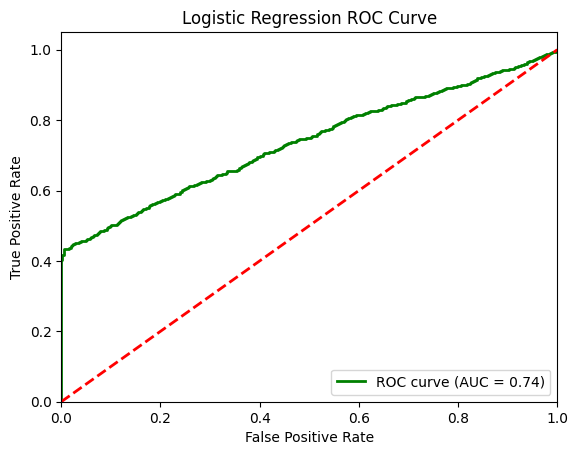

In [48]:
# Import necessary libraries
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt

# 1. Initialize Logistic Regression model
log_model = LogisticRegression(max_iter=500, random_state=42)

# 2. Cross-validation
cv_scores = cross_val_score(log_model, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

# 3. Hyperparameter tuning using GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],        # Regularization strength
    'solver': ['lbfgs', 'liblinear'],     # Solvers for optimization
    'penalty': ['l2']                     # Type of regularization
}

grid_search = GridSearchCV(estimator=log_model, param_grid=param_grid,
                           cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)

# 4. Train Logistic Regression with best parameters
best_log = grid_search.best_estimator_
best_log.fit(X_train, y_train)

# 5. Predict on test set
y_pred = best_log.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

# 6. ROC Curve
y_prob = best_log.predict_proba(X_test)[:, 1]  # Probability for positive class

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='green', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.legend(loc="lower right")
plt.show()


Before SMOTE: [3549 5250]
After SMOTE: [5250 5250]
Cross-validation Accuracy Scores: [0.68095238 0.6952381  0.68571429 0.70904762 0.71      ]
Mean CV Accuracy: 0.6961904761904761
Best Hyperparameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Test Accuracy: 0.6595454545454545


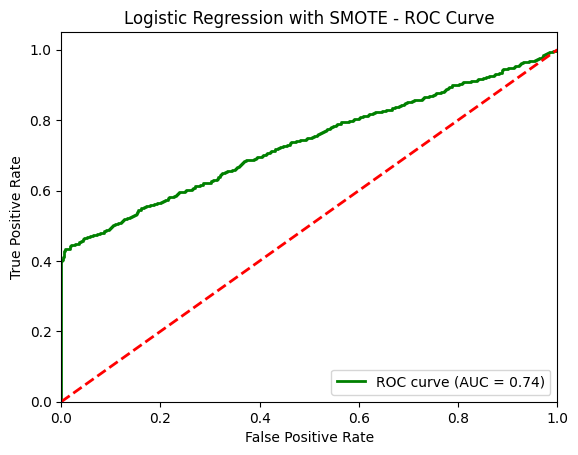

In [49]:
# Import necessary libraries
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, roc_curve, auc
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Apply SMOTE on training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_res))

# 2. Initialize Logistic Regression
log_model = LogisticRegression(max_iter=500, random_state=42)

# 3. Cross-validation (on resampled data)
cv_scores = cross_val_score(log_model, X_train_res, y_train_res, cv=5, scoring='accuracy')
print("Cross-validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

# 4. Hyperparameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}

grid_search = GridSearchCV(estimator=log_model, param_grid=param_grid,
                           cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_res, y_train_res)

print("Best Hyperparameters:", grid_search.best_params_)

# 5. Train best model
best_log = grid_search.best_estimator_
best_log.fit(X_train_res, y_train_res)

# 6. Predict on test set
y_pred = best_log.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

# 7. ROC Curve
y_prob = best_log.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='green', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression with SMOTE - ROC Curve')
plt.legend(loc="lower right")
plt.show()


## Support Vector Machine

Cross-validation scores: [0.7247619  0.72380952 0.71666667 0.73       0.7252381 ]
Mean CV Accuracy: 0.7240952380952381
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross-Validation Accuracy: 0.7291428571428572

Test Accuracy: 0.6681818181818182

Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.92      0.69       887
           1       0.90      0.50      0.64      1313

    accuracy                           0.67      2200
   macro avg       0.73      0.71      0.67      2200
weighted avg       0.76      0.67      0.66      2200


Confusion Matrix:
 [[818  69]
 [661 652]]


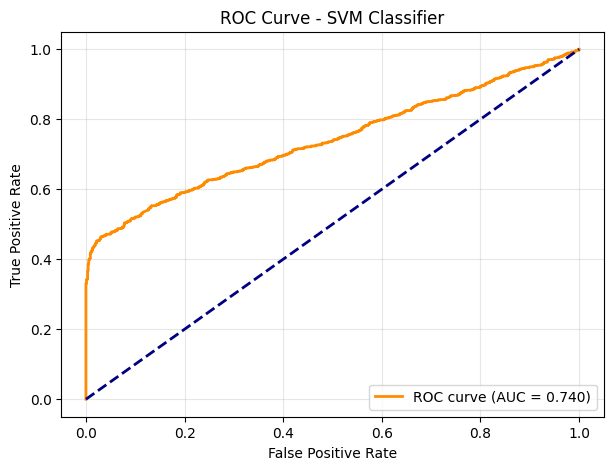

In [19]:
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

svm_clf = SVC(probability=True, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(svm_clf,X_train_res, y_train_res, cv=cv, scoring='accuracy')
print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(
    estimator=svm_clf,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train_res, y_train_res)

print("\nBest Parameters:", grid.best_params_)
print("Best Cross-Validation Accuracy:", grid.best_score_)

best_svm = grid.best_estimator_
y_pred = best_svm.predict(X_test)
y_proba = best_svm.predict_proba(X_test)[:, 1]

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM Classifier')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


## Naive Bayes Classifier

Cross-validation scores: [0.65340909 0.64090909 0.63181818 0.64715909 0.64241046]
Mean CV Accuracy: 0.6431411830068737
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best Parameters: {'var_smoothing': 1e-09}
Best Cross-Validation Accuracy: 0.6431411830068737

Test Accuracy: 0.6404545454545455

Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.99      0.69       887
           1       0.98      0.41      0.57      1313

    accuracy                           0.64      2200
   macro avg       0.75      0.70      0.63      2200
weighted avg       0.80      0.64      0.62      2200


Confusion Matrix:
 [[875  12]
 [779 534]]


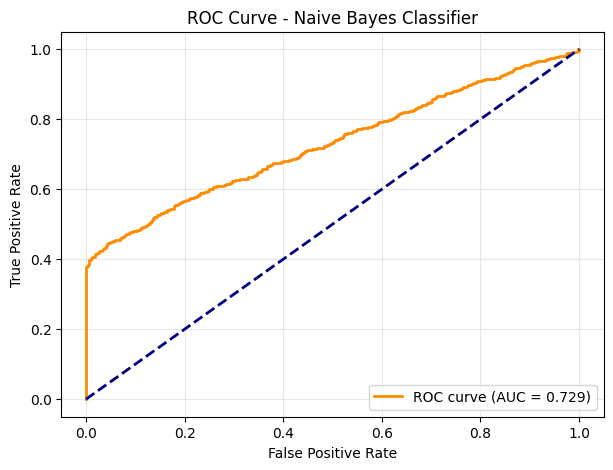

In [ ]:
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

nb_clf = GaussianNB()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(nb_clf, X_train_res, y_train_res, cv=cv, scoring='accuracy')
print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

grid = GridSearchCV(
    estimator=nb_clf,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train_res, y_train_res)

print("\nBest Parameters:", grid.best_params_)
print("Best Cross-Validation Accuracy:", grid.best_score_)

best_nb = grid.best_estimator_
y_pred = best_nb.predict(X_test)
y_proba = best_nb.predict_proba(X_test)[:, 1]

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Naive Bayes Classifier')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


## Random Forest

Cross-validation Accuracy Scores: [0.65113636 0.66022727 0.64659091 0.65397727 0.6822058 ]
Mean CV Accuracy: 0.6588275233862214
Best Hyperparameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Test Accuracy: 0.68


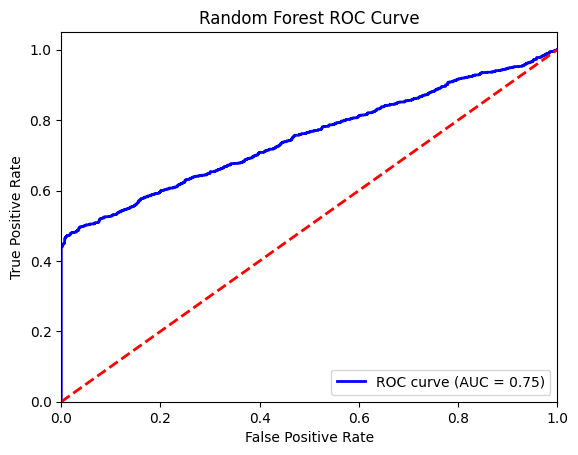

In [ ]:
# Import necessary libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt

# Assuming you already have:
# X_train, X_test, y_train, y_test (after splitting)
# And preprocessing (scaling / one-hot) is done

# 1. Initialize Random Forest
rf = RandomForestClassifier(random_state=42)

# 2. Cross-validation
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

# 3. Hyperparameter tuning using GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)

# 4. Train Random Forest with best parameters
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)

# 5. Predict on test set
y_pred = best_rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

# 6. ROC Curve
# For ROC, we need probability estimates
y_prob = best_rf.predict_proba(X_test)[:, 1]  # probability of positive class

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend(loc="lower right")
plt.show()


## XG Boost

c:\Users\Ramu\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [11:37:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Ramu\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [11:37:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Ramu\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [11:37:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Ramu\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [11:37:56] WARNING: C:\actions-r

Cross-validation Accuracy Scores: [0.65568182 0.64772727 0.62897727 0.63977273 0.66628766]
Mean CV Accuracy: 0.647689350870846


c:\Users\Ramu\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [11:47:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Hyperparameters: {'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}


c:\Users\Ramu\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [11:47:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Test Accuracy: 0.6809090909090909


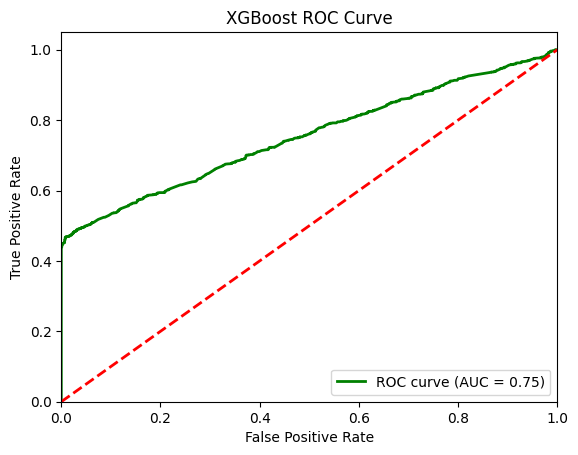

In [ ]:
# Import necessary libraries
import xgboost as xgb
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt

# 1. Initialize XGBoost classifier
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# 2. Cross-validation
cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

# 3. Hyperparameter tuning using GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid,
                           cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)

# 4. Train XGBoost with best parameters
best_xgb = grid_search.best_estimator_
best_xgb.fit(X_train, y_train)

# 5. Predict on test set
y_pred = best_xgb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

# 6. ROC Curve
y_prob = best_xgb.predict_proba(X_test)[:, 1]  # probability of positive class

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='green', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend(loc="lower right")
plt.show()


# SHAP Explainability
import shap

# Create SHAP explainer for the trained XGBoost model
explainer = shap.Explainer(best_xgb)

# Compute SHAP values for test data
shap_values = explainer(X_test)

# 7.1 Summary Plot (Global Feature Importance)
shap.summary_plot(shap_values, X_test)

# 7.2 Bar Plot (Mean absolute SHAP value for each feature)
shap.summary_plot(shap_values, X_test, plot_type="bar")

# 7.3 Force Plot (For a single prediction)
# Pick one test sample to visualize
sample_index = 0
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index].values,
    X_test.iloc[sample_index, :],
    matplotlib=True
)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,      # number of trees
    learning_rate=0.1,     # step size shrinkage
    max_depth=3,           # depth of individual trees
    random_state=42
)

# Train model
gb_model.fit(X_train, y_train)

# Predict
y_pred = gb_model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6768181818181818

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.91      0.69       887
           1       0.89      0.52      0.66      1313

    accuracy                           0.68      2200
   macro avg       0.73      0.71      0.68      2200
weighted avg       0.76      0.68      0.67      2200



AdaBoost

In [ ]:
# Import necessary libraries
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt

# 1. Initialize AdaBoost classifier (with base estimator as Decision Tree)
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    random_state=42
)

# 2. Cross-validation
cv_scores = cross_val_score(ada_model, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

# 3. Hyperparameter tuning using GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
    'estimator__max_depth': [1, 2, 3]
}

grid_search = GridSearchCV(estimator=ada_model, param_grid=param_grid,
                           cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)

# 4. Train AdaBoost with best parameters
best_ada = grid_search.best_estimator_
best_ada.fit(X_train, y_train)

# 5. Predict on test set
y_pred = best_ada.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

# 6. ROC Curve
y_prob = best_ada.predict_proba(X_test)[:, 1]  # probability of positive class

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='green', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AdaBoost ROC Curve')
plt.legend(loc="lower right")
plt.show()
